In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np

In [2]:
df=pd.read_csv('AIML Dataset.csv')

In [3]:
# Try this after you have completed the EDA and feature Engineering .

# df['balance_error_org'] = (
#     df['oldbalanceOrg']
#     - df['amount']
#     - df['newbalanceOrig']
# )

# df['balance_error_dest'] = (
#     df['oldbalanceDest']
#     + df['amount']
#     - df['newbalanceDest']
# )

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df['step'].value_counts()

step
19     51352
18     49579
187    49083
235    47491
307    46968
       ...  
706        4
721        4
693        4
112        2
662        2
Name: count, Length: 743, dtype: int64

In [6]:
df.shape

(6362620, 11)

In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
df.sample(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
947524,44,CASH_OUT,30392.31,C571550753,0.00,0.00,C295879585,473878.71,504271.01,0,0
3569561,260,PAYMENT,925.19,C1728418194,0.00,0.00,M1736784923,0.00,0.00,0,0
3832958,282,PAYMENT,17215.28,C135138132,6457.00,0.00,M17229601,0.00,0.00,0,0
907034,43,PAYMENT,11963.64,C1914672026,2178.00,0.00,M13336695,0.00,0.00,0,0
3031534,233,CASH_OUT,16177.88,C464071061,0.00,0.00,C633211023,137913.59,0.00,0,0
3632275,274,PAYMENT,7729.60,C1399366638,24790.00,17060.40,M257345388,0.00,0.00,0,0
112143,11,CASH_OUT,397491.06,C1738540146,107895.00,0.00,C472732582,0.00,477559.68,0,0
407370,18,PAYMENT,1634.72,C337952014,89923.00,88288.28,M428550994,0.00,0.00,0,0
4714990,332,TRANSFER,339246.81,C1897577968,0.00,0.00,C68336178,14023761.66,14363008.46,0,0
3506124,259,CASH_IN,57934.59,C1284370956,8477446.46,8535381.05,C1917450310,190038.41,132103.82,0,0


In [9]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


<Axes: ylabel='Density'>

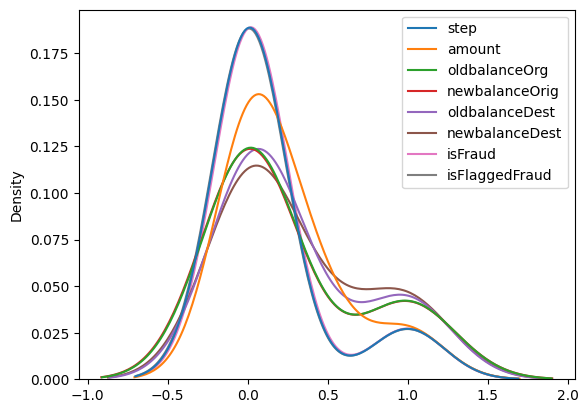

In [11]:
sns.kdeplot(df.corr(numeric_only=True))

### step
###### Data Has some Outliers & Data is right Skewed its required to make it normal distribution

In [12]:
df['step'].value_counts()

step
19     51352
18     49579
187    49083
235    47491
307    46968
       ...  
706        4
721        4
693        4
112        2
662        2
Name: count, Length: 743, dtype: int64

<Axes: ylabel='step'>

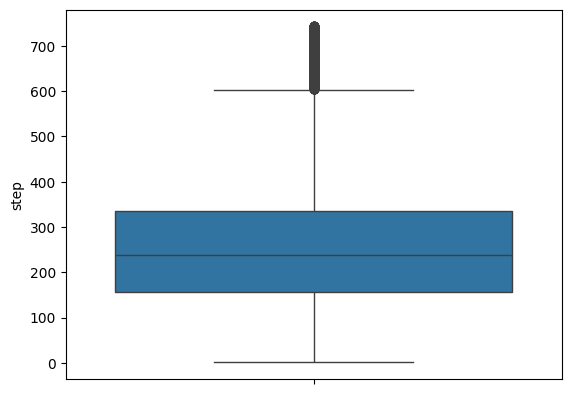

In [13]:
sns.boxplot(df['step'])

<Axes: xlabel='step', ylabel='Count'>

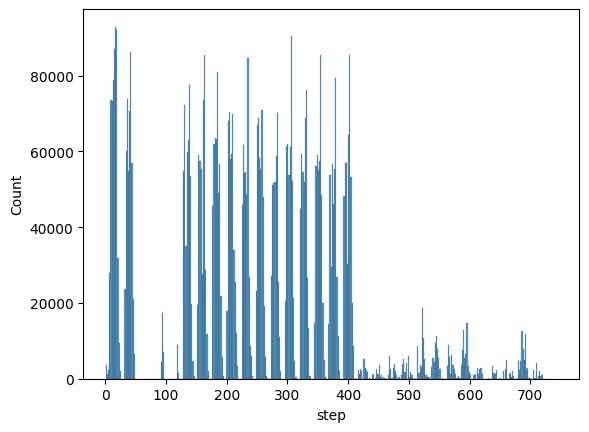

In [14]:
sns.histplot(df['step'])

In [ ]:
sns.kdeplot(df['step'])

In [ ]:
from scipy.stats import skew

print(skew(df['step']))

# Data is right skewed. We can use log transformation to make it normal distribution.


## Type

In [ ]:
df['type'].value_counts()

In [ ]:
# CASH_OUT means money is send to the receiver 
# CASH_IN means money is received from the sender
# PAYMENT means money is send to the receiver for purchasing the product or service
# TRANSFER means money is send to the receiver 

# OneHotEncoding apply for converting categorical data into numerical data 

## amount

In [ ]:
sns.barplot(df['amount'])

In [ ]:
df['amount'].skew()

### Try to create a direct pipeline

In [4]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,orig_type,dest_type
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,C,M
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,C,M


In [3]:
df['orig_type'] = df['nameOrig'].str[0]
df['dest_type'] = df['nameDest'].str[0]

In [5]:
x=df[['type','amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','orig_type','dest_type']]
y=df['isFraud']

In [ ]:
# Cat_cols -> OneHotEncoding
# num_cols -> StandardScaler

cat_cols =['type','orig_type','dest_type']
num_cols=['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']



In [7]:
cat_cols

['type', 'orig_type', 'dest_type']

In [10]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.linear_model import LogisticRegression




In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
num_pipe=Pipeline([
    ('scaler',StandardScaler())
])

In [14]:
cat_pipe = Pipeline([
    ('encoder', OneHotEncoder(drop='first'))
])

In [15]:
preprocess= ColumnTransformer([
    ('num',num_pipe,num_cols),
    ('cat',cat_pipe,cat_cols)
],remainder='passthrough')

In [16]:
pipe = Pipeline([
    ('preprocess',preprocess),
    ('classifier',LogisticRegression())
])

In [17]:
pipe.fit(x_train,y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
y_pred=pipe.predict(x_test)

In [19]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.96      0.32      0.47      1620

    accuracy                           1.00   1272524
   macro avg       0.98      0.66      0.74   1272524
weighted avg       1.00      1.00      1.00   1272524



In [20]:
print(accuracy_score(y_test,y_pred))

0.9991120010310218


In [21]:
print(confusion_matrix(y_test, y_pred))

[[1270883      21]
 [   1109     511]]


In [22]:
import numpy as np
print(np.bincount(y_test))

[1270904    1620]


## RandomForestClassifier

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ('preprocess',preprocess),
    ('classifier',RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
    ))
])

rf_pipe.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
y_pred_rf = rf_pipe.predict(x_test)

# Accuracy Score
print("Accuracy Score:", accuracy_score(y_test, y_pred_rf))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy Score: 0.9996966658389154
Confusion Matrix:
[[1270855      49]
 [    337    1283]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.96      0.79      0.87      1620

    accuracy                           1.00   1272524
   macro avg       0.98      0.90      0.93   1272524
weighted avg       1.00      1.00      1.00   1272524



#### now see the recall 0.79 for the fraud detection and f1_score has 0.87 its good for deploying the model , but i will also try the another model